# 흉부 X-ray 폐렴 분류

Baseline의 흐름
- Dataset → DataLoader → 학습 → 예측 → 제출
| # | 바꾼 점 | 이유 |
|---|---|---|
| 1 | **test 이미지를 letterbox(비율 유지 + 검은 여백)로 리사이즈** | train 이미지는 이미 이 방식으로 224×224가 되어 있음. test를 그냥 늘리면(Resize) train과 모양이 달라짐 |
| 2 | **ImageNet으로 사전학습된 EfficientNet-B0** 사용 (전이학습) | 5,216장은 CNN을 처음부터 학습하기엔 적은 양 |
| 3 | **검증(validation) 데이터 20% 분리** | 제출 전에 정확도를 스스로 확인하고, 가장 좋은 에포크의 모델을 저장 |
| 4 | **클래스 가중치** (정상 1,341장 vs 폐렴 3,875장) | 모델이 "전부 폐렴"으로 찍는 쪽으로 쏠리는 것을 막음 |
| 5 | **데이터 증강** (회전·이동·확대·밝기) | 같은 사진을 조금씩 다르게 보여줘서 과적합 방지 |

평가 산식: **Accuracy**

## 0. 데이터 준비
데이터 폴더(`train/`, `test/`, `train.csv`, `test.csv`, `sample_submission.csv`)가 있는 경로를 `DATA_DIR`에 적어 주세요.
맥(M1/M2)에서는 GPU 역할을 하는 **mps**가 자동으로 사용됩니다.

VS Code에서 처음 실행할 때 오른쪽 위 **커널 선택**에서 torch가 설치된 파이썬을 고르세요. 라이브러리가 없다면 아래 명령을 터미널에서 한 번 실행합니다.
`pip install torch torchvision scikit-learn pandas matplotlib pillow`

In [ ]:
import os

DATA_DIR = "."     # 데이터가 들어 있는 폴더 경로 (본인 경로에 맞게 수정)
os.chdir(DATA_DIR)

print(os.getcwd())                                 # 현재 작업 폴더 확인
print(os.listdir())
print("train 이미지 수:", len(os.listdir("train")))
print("test 이미지 수:", len(os.listdir("test")))

.
['.DS_Store', 'test', 'test.csv', 'train', 'train.csv', 'xray_improved.ipynb', 'sample_submission.csv']
train 이미지 수: 5216
test 이미지 수: 624


## 1. 라이브러리 불러오기
baseline과 같고, 사전학습 모델을 쓰기 위해 `torchvision.models`, 검증 데이터를 나누기 위해 `train_test_split`, 결과 확인용 `accuracy_score`, `confusion_matrix`를 추가했습니다.

In [2]:
import os, random                      # os: 파일 경로 다루기 / random: 파이썬 난수
import numpy as np, pandas as pd       # numpy: 숫자 배열 계산 / pandas: CSV 표 다루기
from PIL import Image                  # 이미지 파일 열기·자르기·붙이기
import matplotlib.pyplot as plt        # 그림(이미지, 그래프) 그리기

import torch                                        # PyTorch 핵심
import torch.nn as nn                               # 신경망 층(Linear 등)과 손실함수
import torch.optim as optim                         # 옵티마이저(AdamW)와 학습률 스케줄러
from torch.utils.data import Dataset, DataLoader    # 데이터를 모델에 배치 단위로 넣어주는 도구
from torchvision import transforms, models          # transforms: 이미지 전처리·증강 / models: 사전학습 모델 모음

from sklearn.model_selection import train_test_split          # 학습/검증 데이터 나누기
from sklearn.metrics import accuracy_score, confusion_matrix  # 정확도(대회 평가 산식), 혼동행렬

# 실행할 때마다 결과가 같도록 시드 고정
random.seed(42); np.random.seed(42); torch.manual_seed(42)   # 파이썬·numpy·torch 난수를 모두 42로 고정

# GPU가 있으면 GPU(cuda), 맥이면 mps, 없으면 cpu
if torch.cuda.is_available():                 # 코랩 GPU(T4 등)가 있으면
    device = torch.device("cuda")
elif torch.backends.mps.is_available():       # 맥(M1/M2) GPU가 있으면
    device = torch.device("mps")
else:                                         # 둘 다 없으면 CPU (매우 느림)
    device = torch.device("cpu")
print(device)                                 # 코랩에서는 'cuda'가 나와야 정상

mps


## 2. 데이터 살펴보기
- 라벨 : 
    0 = 정상, 1 = 폐렴 - 폐렴이 약 3배 많음(불균형)
- **train 이미지는 전부 224×224**
- **test 이미지는 원본 크기 그대로**(수백~2천 픽셀)

In [ ]:
train_df = pd.read_csv("train.csv")        # 학습 표: file_name(파일명), label(0=정상, 1=폐렴)
test_df = pd.read_csv("test.csv")          # 테스트 표: file_name만 있음 (정답 없음)
print(train_df["label"].value_counts())    # 라벨별 개수 → 1(폐렴) 3875, 0(정상) 1341

# 이미지 크기 확인
for f in train_df["file_name"][:5]:
    print("train", f, Image.open("train/" + f).size)   # .size = (가로, 세로)
for f in test_df["file_name"][:5]:
    print("test ", f, Image.open("test/" + f).size)

label
1    3875
0    1341
Name: count, dtype: int64
train train_0001.png (224, 224)
train train_0002.png (224, 224)
train train_0003.png (224, 224)
train train_0004.png (224, 224)
train train_0005.png (224, 224)
test  test_0001.png (1936, 1554)
test  test_0002.png (1612, 941)
test  test_0003.png (1528, 968)
test  test_0004.png (904, 552)
test  test_0005.png (1365, 1118)


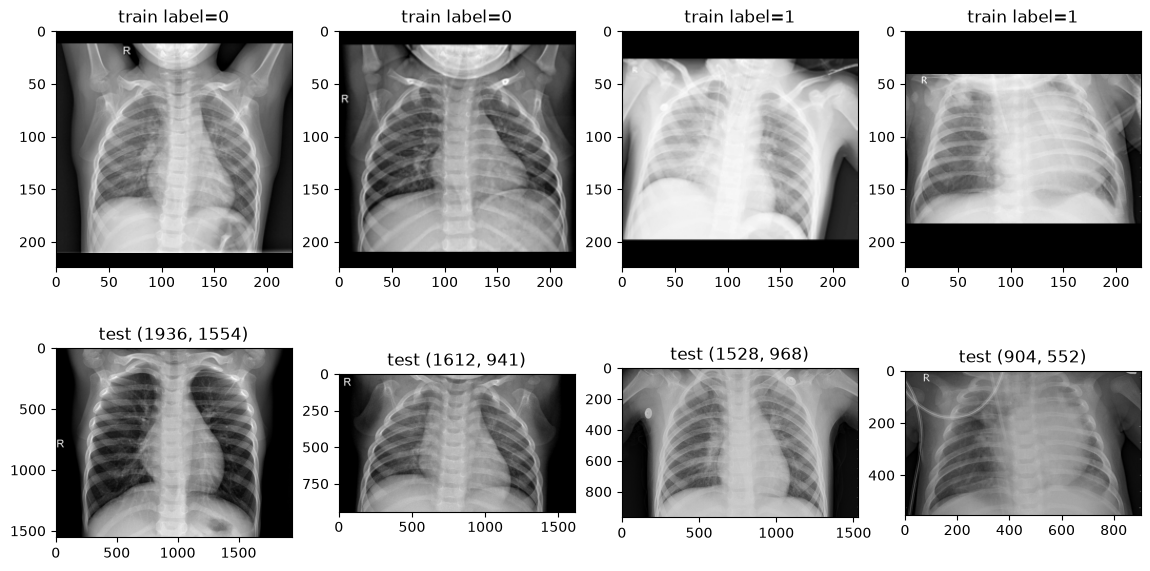

In [ ]:
# train 이미지 4장, test 이미지 4장 그려보기
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i in range(4):
    f = train_df["file_name"][i * 1000]                                     # 0, 1000, 2000, 3000번째 train 이미지
    axes[0, i].imshow(Image.open("train/" + f), cmap="gray")                # 흑백으로 표시
    axes[0, i].set_title(f"train label={train_df['label'][i * 1000]}")      # 제목에 정답 라벨 표시
    f = test_df["file_name"][i]
    axes[1, i].imshow(Image.open("test/" + f), cmap="gray")
    axes[1, i].set_title("test " + str(Image.open("test/" + f).size))       # 제목에 원본 크기 표시

plt.show()

## 3. 이미지 전처리

**letterbox** : 
- 이미지를 가로세로 비율을 유지한 채 224 안에 들어가게 줄이고, 남는 부분을 검은색으로 채움. 
- train과 똑같은 모양을 만들기 위해 test(와 검증)에 사용

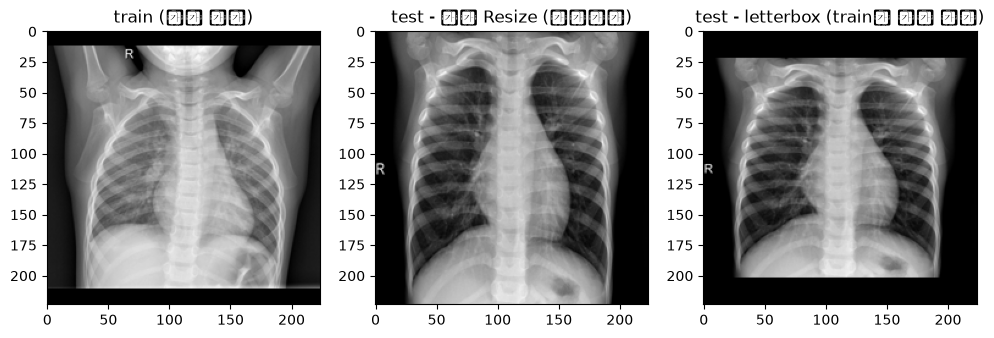

In [8]:
IMG_SIZE = 224    # 모델에 넣을 이미지 크기 (train 이미지 크기와 같게)

def letterbox(img):
    img = img.copy()
    img.thumbnail((IMG_SIZE, IMG_SIZE))                 # 비율 유지하며 긴 변을 224로 줄이기
    canvas = Image.new("L", (IMG_SIZE, IMG_SIZE), 0)    # 224×224 검은 도화지 ("L"=흑백, 0=검정)
    x = (IMG_SIZE - img.size[0]) // 2                   # 가로 여백의 절반 → 왼쪽 시작 위치
    y = (IMG_SIZE - img.size[1]) // 2                   # 세로 여백의 절반 → 위쪽 시작 위치 (예: (224-140)//2 = 42)
    canvas.paste(img, (x, y))                           # 가운데에 붙이기 → 위아래(또는 좌우)가 검은 띠
    return canvas

# 학습용: 매번 조금씩 다르게 변형(증강)
train_tf = transforms.Compose([
    transforms.RandomAffine(degrees=10, translate=(0.05, 0.05), scale=(0.9, 1.1)),  # ±10도 회전, 상하좌우 5% 이동, 0.9~1.1배 확대/축소
    transforms.ColorJitter(brightness=0.2, contrast=0.2),                           # 밝기·대비를 ±20% 범위에서 무작위로 변경
    transforms.Grayscale(3),                                                        # 흑백 1채널 → 같은 값 3채널 (사전학습 모델은 RGB 입력)
    transforms.ToTensor(),                                                          # PIL 이미지 → 텐서, 픽셀 0~255 → 0~1
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),             # ImageNet 평균/표준편차로 정규화
])

# 검증/테스트용: 변형 없이
eval_tf = transforms.Compose([
    transforms.Grayscale(3),                                                # 학습 때와 똑같이 3채널로
    transforms.ToTensor(),                                                  # 텐서 변환
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),     # 같은 정규화 (증강은 하지 않음 → 매번 같은 결과)
])

# letterbox 결과 확인: test 원본을 그냥 늘린 것 vs letterbox
img = Image.open("test/" + test_df["file_name"][0]).convert("L")   # test 첫 장을 흑백으로 열기
fig, axes = plt.subplots(1, 3, figsize=(12, 4))                      # 1행 3열로 비교
axes[0].imshow(Image.open("train/" + train_df["file_name"][0]), cmap="gray"); axes[0].set_title("train (원래 모양)")
axes[1].imshow(img.resize((IMG_SIZE, IMG_SIZE)), cmap="gray"); axes[1].set_title("test - 그냥 Resize (찌그러짐)")
axes[2].imshow(letterbox(img), cmap="gray"); axes[2].set_title("test - letterbox (train과 같은 모양)")

plt.show()

## 4. Dataset 만들기
- CSV 경로 대신 **DataFrame**을 받아서, 학습용/검증용으로 나눈 표를 각각 넣기
- 전처리(`tf`)를 바깥에서 골라 넣기
- 이미지를 열자마자 `letterbox`를 적용

In [9]:
class TrainCSV(Dataset):
    def __init__(self, df, root_dir, tf):
        self.files = df["file_name"].tolist()               # 파일명 목록
        self.labels = df["label"].astype(int).tolist()      # 정답 목록 (0/1)
        self.root, self.tf = root_dir, tf                   # 이미지 폴더, 적용할 전처리
    def __len__(self): return len(self.files)               # 데이터 개수
    def __getitem__(self, i):                               # i번째 데이터를 요청하면
        img = Image.open(os.path.join(self.root, self.files[i])).convert("L")   # 이미지를 흑백으로 열고
        x = self.tf(letterbox(img))                         # letterbox로 224×224 만든 뒤 전처리
        y = self.labels[i]                                  # 정답
        return x, y                                         # (이미지 텐서, 정답) 반환

class TestCSV(Dataset):
    def __init__(self, df, root_dir, tf):
        self.files = df["file_name"].tolist()               # 파일명 목록 (test는 정답 없음)
        self.root, self.tf = root_dir, tf
    def __len__(self): return len(self.files)
    def __getitem__(self, i):
        img = Image.open(os.path.join(self.root, self.files[i])).convert("L")
        x = self.tf(letterbox(img))                         # 원본 크기 test도 train과 같은 모양으로
        return x                                            # 이미지만 반환

## 5. 학습 / 검증 나누기 + DataLoader

In [ ]:
tr_df, val_df = train_test_split(train_df, test_size=0.2, random_state=42, stratify=train_df["label"])       # stratify=  : 정상/폐렴 비율을 양쪽에 똑같이
print("학습:", len(tr_df), " 검증:", len(val_df))

train_loader = DataLoader(TrainCSV(tr_df, "train", train_tf), batch_size=32, shuffle=True)      # 학습 : 증강 O, 순서 섞기
val_loader   = DataLoader(TrainCSV(val_df, "train", eval_tf), batch_size=64, shuffle=False)     # 검증 : 증강 X 
test_loader  = DataLoader(TestCSV(test_df, "test", eval_tf), batch_size=64, shuffle=False)      # 테스트

학습: 4172  검증: 1044


## 6. 모델: 사전학습된 EfficientNet-B0
ImageNet(사진 120만 장)으로 이미 학습된 모델을 가져와서, 마지막 분류층만 **2개 클래스(정상/폐렴)** 로 바꿉니다.
선·모서리·질감 같은 기본 특징은 이미 배운 상태라 적은 데이터로도 빠르게 잘 학습됩니다.

In [11]:
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)    # ImageNet으로 학습된 가중치까지 불러오기
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)                     # 마지막 층: 원래 1000개 클래스 → 2개(정상/폐렴)로 교체
model = model.to(device)                                                                # 모델을 GPU로 옮기기

## 7. 학습 준비: 클래스 가중치 + 옵티마이저
정상 사진이 적으므로 정상을 틀렸을 때 손실을 더 크게 줍니다.
`가중치 = 전체 수 / (2 × 그 클래스 수)` → 정상 ≈ 1.94, 폐렴 ≈ 0.67

사전학습 모델은 이미 좋은 상태라 학습률을 baseline(0.001)보다 작은 0.0001로 조금씩만 조정합니다.

In [13]:
n0 = (tr_df["label"] == 0).sum()     # 학습용 정상 개수 (1073)
n1 = (tr_df["label"] == 1).sum()     # 학습용 폐렴 개수 (3099)
class_weight = torch.tensor([len(tr_df) / (2 * n0), len(tr_df) / (2 * n1)], dtype=torch.float32).to(device)  # [정상 가중치, 폐렴 가중치]
print("클래스 가중치:", class_weight)   # 약 [1.94, 0.67] → 정상을 틀리면 약 3배 더 크게 벌점

criterion = nn.CrossEntropyLoss(weight=class_weight)                        # 클래스 가중치를 적용한 손실함수
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)     # 학습률 0.0001, weight_decay: 가중치가 너무 커지지 않게 규제
epochs = 10
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)  # 학습률을 코사인 곡선처럼 점점 줄여 마지막엔 미세 조정

클래스 가중치: tensor([1.9441, 0.6731], device='mps:0')


## 8. 학습 + 검증
**매 에포크마다 검증 정확도를 계산**
- 검증 정확도가 가장 높았던 에포크의 모델을 `best_model.pt`로 저장

In [14]:
best_acc = 0       # 지금까지 가장 높은 검증 정확도
history = []       # 에포크별 검증 정확도 기록 (그래프용)
for ep in range(epochs):
    # --- 학습 ---
    model.train(); running = 0.0                      # 학습 모드 (Dropout 등 켜짐), 손실 합계 초기화
    for x, y in train_loader:                         # 32장씩 꺼내서
        x, y = x.to(device), y.to(device)             # GPU로 옮기고
        logits = model(x)                             # 순전파: 클래스별 점수 계산
        loss = criterion(logits, y)                   # 정답과 비교해 손실 계산
        optimizer.zero_grad(); loss.backward(); optimizer.step()   # 기울기 초기화 → 역전파 → 가중치 업데이트
        running += loss.item() * x.size(0)           # 배치 손실 × 배치 크기 누적 (평균 손실 계산용)
    scheduler.step()                                  # 에포크가 끝날 때마다 학습률 조금 줄이기

    # --- 검증 ---
    model.eval(); val_preds = []                      # 평가 모드 (Dropout 등 꺼짐)
    with torch.no_grad():                             # 기울기 계산 안 함 → 빠르고 메모리 절약
        for x, y in val_loader:
            val_preds.extend(model(x.to(device)).argmax(1).cpu().numpy())   # 점수가 큰 쪽(0 또는 1)을 예측으로
    val_acc = accuracy_score(val_df["label"], val_preds)   # 검증 정확도 = 맞힌 개수 / 전체
    history.append(val_acc)

    print(f"Epoch {ep+1} | loss {running/len(tr_df):.4f} | val acc {val_acc:.4f}")
    if val_acc > best_acc:                                # 최고 기록을 넘으면
        best_acc = val_acc
        torch.save(model.state_dict(), "best_model.pt")   # 그 시점의 가중치를 파일로 저장

print("최고 검증 정확도:", best_acc)

Epoch 1 | loss 0.2103 | val acc 0.9789
Epoch 2 | loss 0.0939 | val acc 0.9751
Epoch 3 | loss 0.0597 | val acc 0.9693
Epoch 4 | loss 0.0569 | val acc 0.9789
Epoch 5 | loss 0.0520 | val acc 0.9799
Epoch 6 | loss 0.0362 | val acc 0.9847
Epoch 7 | loss 0.0278 | val acc 0.9856
Epoch 8 | loss 0.0315 | val acc 0.9828
Epoch 9 | loss 0.0229 | val acc 0.9875
Epoch 10 | loss 0.0246 | val acc 0.9875
최고 검증 정확도: 0.9875478927203065


## 9. 검증 결과 자세히 보기
가장 좋았던 모델을 다시 불러와서 혼동행렬로 어떤 쪽을 틀리는지 확인

검증 정확도: 0.9875478927203065
[[263   5]
 [  8 768]]


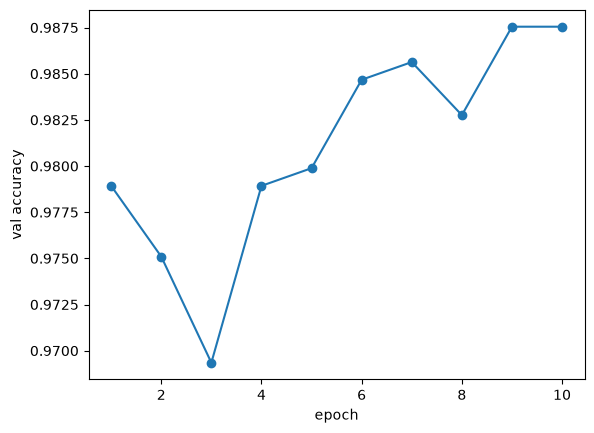

In [15]:
model.load_state_dict(torch.load("best_model.pt", map_location=device))     # 마지막 에포크가 아니라 '최고' 에포크의 가중치로 되돌리기
model.eval()                                                                # 평가 모드
val_prob = []
with torch.no_grad():
    for x, y in val_loader:
        val_prob.extend(torch.softmax(model(x.to(device)), 1)[:, 1].cpu().numpy())   # softmax로 점수→확률, [:, 1] = 폐렴일 확률
val_prob = np.array(val_prob)

print("검증 정확도:", accuracy_score(val_df["label"], val_prob > 0.5))   # 폐렴 확률 0.5 초과면 폐렴(1)으로 판정
print(confusion_matrix(val_df["label"], val_prob > 0.5))              # [[정상→정상, 정상→폐렴], [폐렴→정상, 폐렴→폐렴]]

plt.plot(range(1, epochs + 1), history, marker="o")        # 에포크별 검증 정확도 그래프
plt.xlabel("epoch"); plt.ylabel("val accuracy"); plt.show()

## 10. 테스트 예측 (+ 좌우반전 TTA)
**원본과 좌우반전한 이미지의 예측 확률을 평균**(TTA, Test Time Augmentation).

In [16]:
test_prob = []
with torch.no_grad():                                                  # 예측만 하므로 기울기 계산 X
    for x in test_loader:                                              # 64장씩 (순서 그대로)
        x = x.to(device)
        p1 = torch.softmax(model(x), 1)[:, 1]                          # 원본 이미지의 폐렴 확률
        p2 = torch.softmax(model(torch.flip(x, dims=[3])), 1)[:, 1]    # 좌우반전 이미지의 폐렴 확률 (dims=[3] = 가로 방향)
        test_prob.extend(((p1 + p2) / 2).cpu().numpy())                # 두 확률의 평균
test_prob = np.array(test_prob)
all_preds = (test_prob > 0.5).astype(int)                              # 0.5 초과 → 1(폐렴), 아니면 0(정상)

# 참고용: 예측 결과가 한쪽으로 심하게 쏠리지 않았는지 확인
print("test에서 폐렴으로 예측한 비율:", all_preds.mean().round(3), "(train 폐렴 비율:", train_df["label"].mean().round(3), ")")

test에서 폐렴으로 예측한 비율: 0.766 (train 폐렴 비율: 0.743 )


## 11. 제출 파일 만들기

In [17]:
submission = pd.read_csv("sample_submission.csv")    # 제출 양식 (test 파일명 순서 그대로)
submission["label"] = all_preds                      # 예측 결과를 label 칸에 채우기
submission.to_csv("submission.csv", index=False)     # index=False: 행 번호 없이 저장 → 이 파일을 제출
submission.head()                                    # 앞 5줄 확인

,file_name,label
0,test_0001.png,1
1,test_0002.png,1
2,test_0003.png,1
3,test_0004.png,1
4,test_0005.png,1
